Основано на практическом курсе RL от YSDA

В этой тетради вы должны освоить Q-learning и еще раз применить его к задачам RL.

Чтобы привыкнуть к пакету`gymnasium`, пожалуйста, ознакомьтесь с [документацией](https://gymnasium.farama.org/introduction/basic_usage/).

В конце блокнота, пожалуйста, скопируйте реализованные вами функции в файл шаблона и отправьте его на конкурс.

In [4]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Step 1: Tabular Q-learning with SoftMax polic

Мы хотим, чтобы вы внедрили алгоритм Q-learning с помощью политики softmax.

Вам необходимо внедрить QLearningAgent (следуйте инструкциям для каждого метода) и использовать его в ряде тестов, приведенных ниже.

Политика SoftMax означает, что вероятности действий вычисляются на основе значений q с использованием функции softmax, где $\tau$ - температура softmax:

$$ \pi(a_i \mid s) = \operatorname{softmax} \left( \left\{ {Q(s, a_j) \over \tau} \right\}_{j=1}^n \right)_i = {\operatorname{exp} \left( Q(s,a_i) / \tau \right)  \over {\sum_{j}  \operatorname{exp} \left( Q(s,a_j) / \tau  \right)}} $$

Сначала реализуйте softmax. Не забывайте, что показатель степени с большим значением может быть слишком большим, чтобы поместиться в float. Вычтите максимум для числовой стабильности.

In [10]:
def my_softmax(values: np.ndarray, T=1.):
    values = values - max(values)
    probas = np.zeros(values.shape[0])
    s = np.sum(np.exp(values / T))
    for i, value in enumerate(values):
        probas[i] = np.exp(value / T) / s
    assert probas is not None
    return probas

Теперь проверьте свой Softmax с помощью следующих тестов.

In [11]:
import torch
test_data = np.arange(5)
for temp in [0.1, 0.5, 1, 5]:
    local_softmax = my_softmax(test_data, T=temp)
    with torch.no_grad():
        torch_softmax = torch.softmax(torch.from_numpy(test_data)/temp, dim=-1)
    assert np.allclose(local_softmax, torch_softmax.numpy())
    print(f'Passed for temp={temp}')

Passed for temp=0.1
Passed for temp=0.5
Passed for temp=1
Passed for temp=5


Простая визуализация для вашего удобства

Text(0.5, 1.0, 'Example softmax with temp = 1')

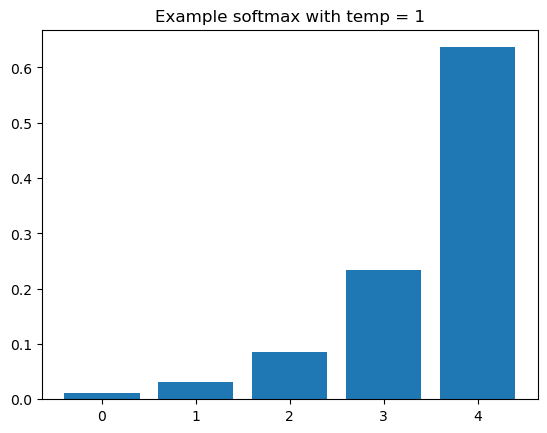

In [12]:
temp = 1
plt.bar(test_data, my_softmax(test_data, T=temp))
plt.title(f'Example softmax with temp = {temp}')

Теперь реализуйте `QLearningAgent`.

In [122]:
import random
from collections import defaultdict


class QLearningAgent:
    def __init__(self, alpha, discount, get_legal_actions, temp=1.):
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.discount = discount
        self.temp = temp

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return 0.0
        actions = self.get_legal_actions(state)
        value = max([self.get_qvalue(state, action) for action in actions])
        assert value is not None
        return value

    def update(self, state, action, reward, next_state):
        gamma = self.discount
        learning_rate = self.alpha
        qvalue = (1 - learning_rate) * self.get_qvalue(state, action) + \
            learning_rate * (reward + gamma * self.get_value(next_state))
        assert qvalue is not None
        self.set_qvalue(state, action, qvalue)

    def get_best_action(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        maxq = -float("inf")
        best_action = None
        for action in possible_actions:
            q = self.get_qvalue(state, action)
            if maxq < q:
                maxq = q
                best_action = action
        assert best_action is not None
        return best_action

    def get_softmax_policy(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        q_values = [self.get_qvalue(state, action) for action in possible_actions]
        q_values = np.asarray(q_values)
        assert q_values is not None
        q_values - max(q_values)
        probabilities = my_softmax(q_values)
        assert probabilities is not None
        return probabilities

    def get_action(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        actions_probabilities = self.get_softmax_policy(state)
        chosen_action = np.random.choice(possible_actions, p=actions_probabilities)
        assert chosen_action is not None
        return chosen_action

### Попробуйте это в taxi

Здесь мы используем Q-Learning agent в среде Taxi-v3 от OpenAI gym.
Вам нужно будет выполнить несколько его функций.

In [123]:
import gymnasium as gym

env = gym.make("Taxi-v3", render_mode="rgb_array")

n_actions = env.action_space.n

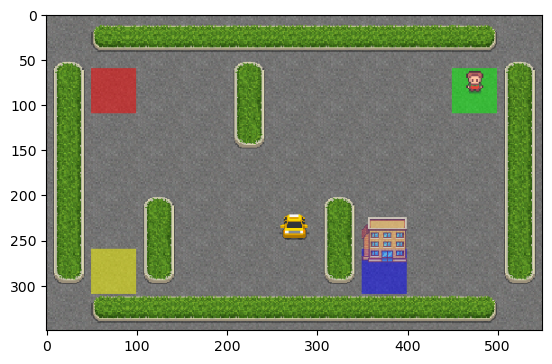

In [124]:
s, _ = env.reset()
plt.imshow(env.render())

In [125]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [126]:
def play_and_train(env, agent, t_max=10**4):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        a = agent.get_action(s)

        next_s, r, done, _, _ = env.step(a)

        # train (update) agent for state s
        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

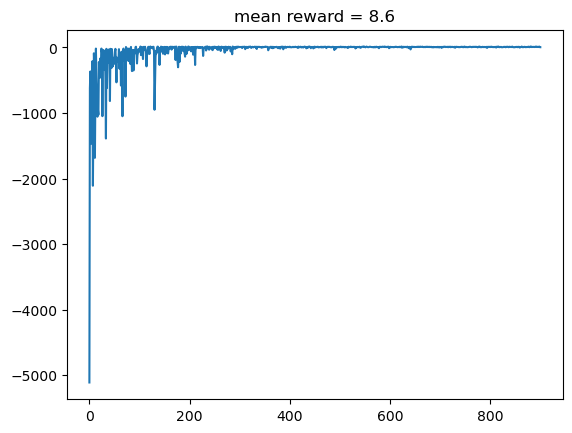

In [127]:
from IPython.display import clear_output

rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))

    if i % 100 == 0:
        clear_output(True)
        plt.title("mean reward = {:.1f}".format(np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.show()

## Step 2: Discretized state spaces.



Давайте попробуем решить ту же задачу `CartPole-v1` с помощью `Tabular Q-learning`.

Эта среда имеет непрерывный набор возможных состояний, поэтому нам придется каким-то образом сгруппировать их в ячейки.

Простая бинаризация уже присутствует. Вы можете поиграть с ним, чтобы посмотреть, что получится.

Самый простой способ - использовать `round(x, n_digits)` (или `np.round`), чтобы округлить действительное число до заданного количества цифр. Сложная часть заключается в том, чтобы правильно задать `n_digits` для каждого состояния для эффективного обучения.

Обратите внимание, что вам не нужно преобразовывать состояние в целые числа, а в __tuples__ любых значений.

first state: [0.04538238 0.03396848 0.02804803 0.03651894]


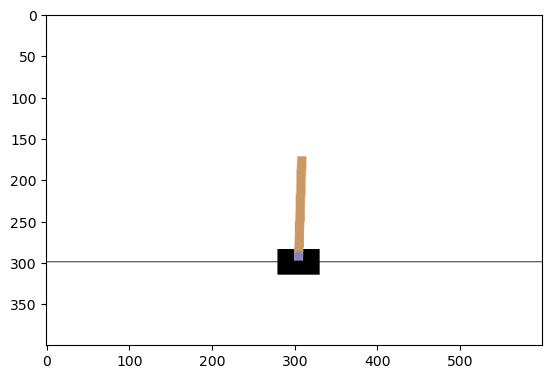

In [128]:
def make_env():
    return gym.make("CartPole-v1", render_mode="rgb_array")

env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())

### Сыграйте в несколько игр

Нам нужно оценить распределение наблюдений. Для этого мы сыграем в несколько игр и запишем все состояния.

In [131]:
def visualize_cartpole_observation_distribution(seen_observations):
    seen_observations = np.array(seen_observations)

    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    # ["Положение тележки", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]
    titles = ["Положение", "Скорость", "Угол наклона", "Скорость Полюса На Кончике"]

    f, axarr = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
    for i, title in enumerate(titles):
        ax = axarr[i // 2, i % 2]
        ax.hist(seen_observations[:, i], bins=20)
        ax.set_title(title)
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

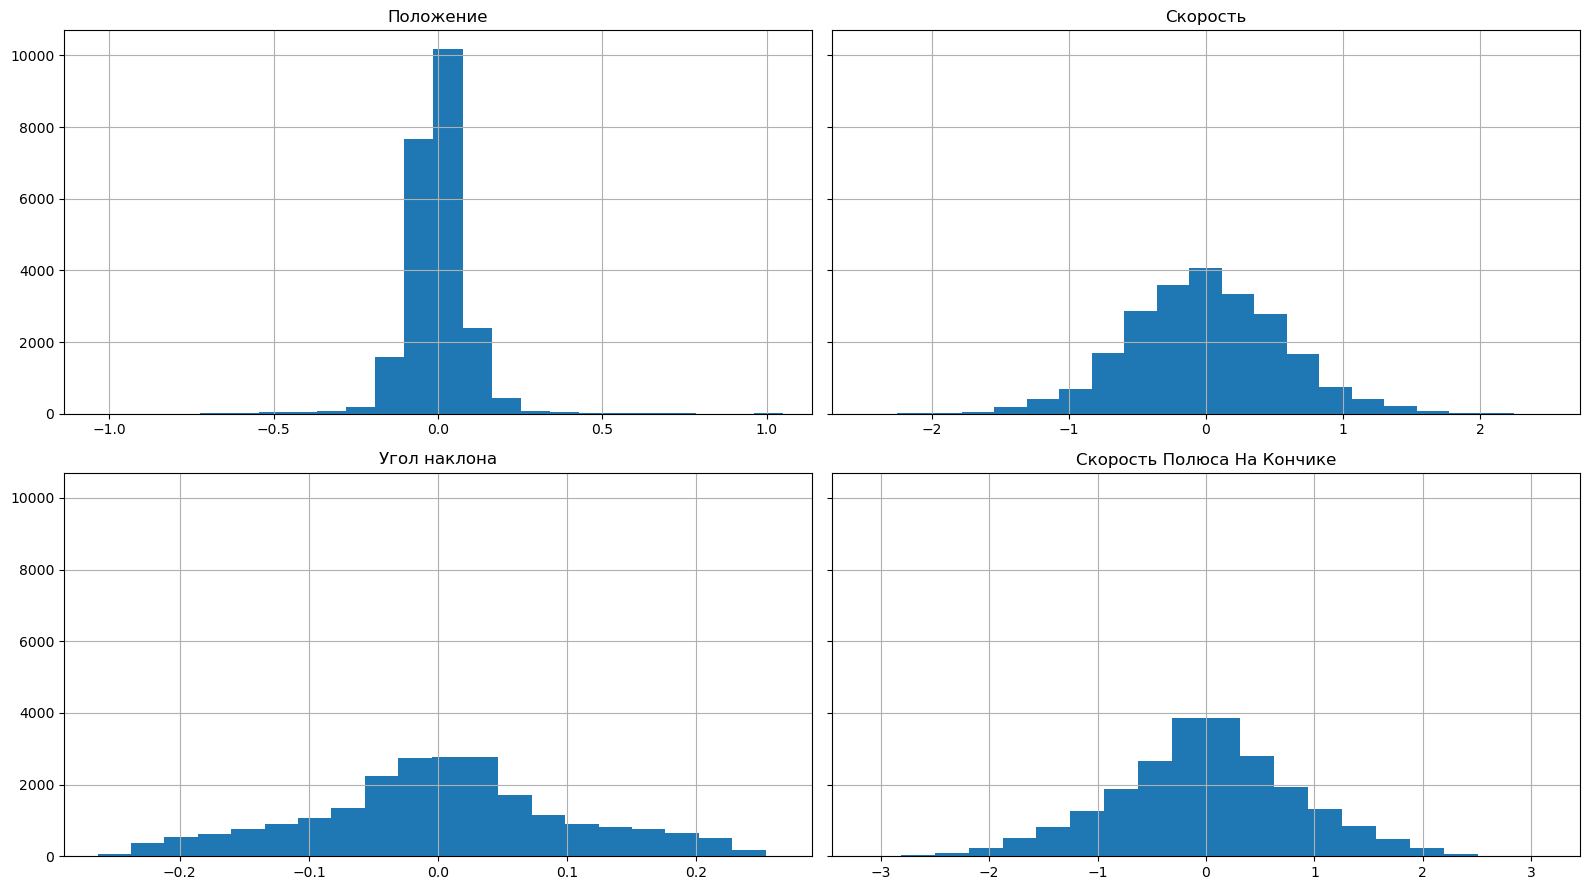

In [132]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)

visualize_cartpole_observation_distribution(seen_observations)

### Дискретная среда

In [134]:
from gymnasium.core import ObservationWrapper


class Discretizer(ObservationWrapper):
    def observation(self, state):
        # Подсказка: это можно сделать с помощью round(x, n_digits).
        # Вы можете выбрать разное значение n_digits для каждого измерения.
        features_ndigits = [1, 1, 1, 1]
        for feature_index in range(len(state)):
            state[feature_index] = round(state[feature_index], features_ndigits[feature_index])
        return tuple(state)

In [135]:
env = Discretizer(make_env())

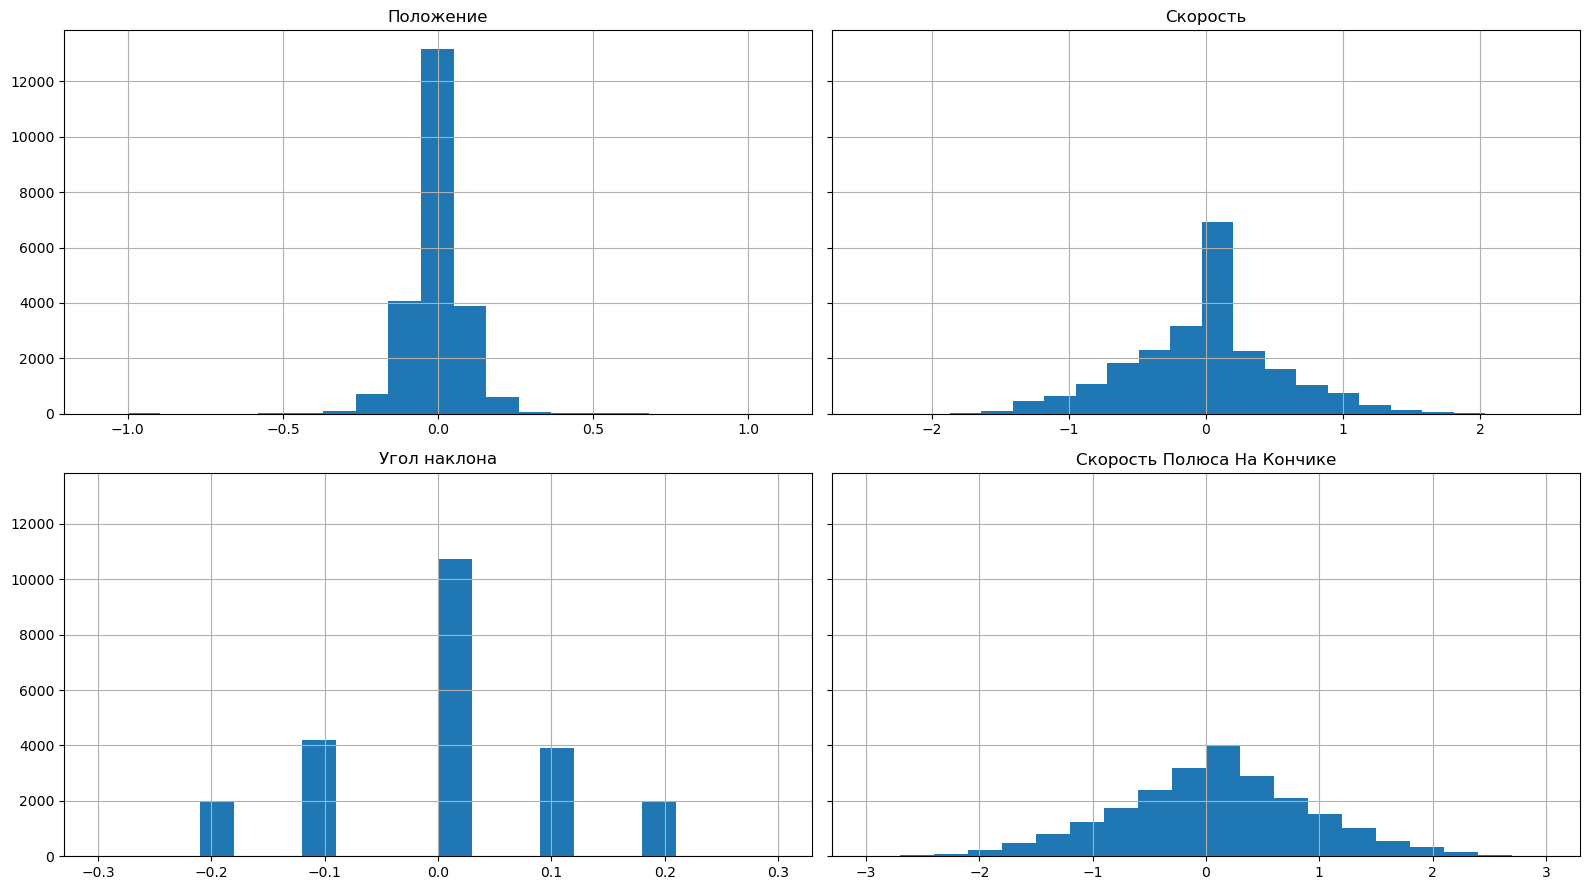

In [136]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)
        if done:
            break

visualize_cartpole_observation_distribution(seen_observations)

### Изучите дискретную политику

Теперь давайте обучим политику, которая использует дискретизированное пространство состояний.

__Советы:__

* Обратите внимание, что увеличение количества цифр для одного измерения наблюдений увеличивает пространство состояний в $10$ раз.
* Если дискретизация слишком мелкая, сходимость агента будет значительно дольше $10000$ шагов. Можно либо увеличить количество итераций и уменьшить спад температуры softmax, либо изменить дискретизацию. На практике мы обнаружили, что подобные ошибки встречаются довольно часто.
* Если дискретизация слишком грубая, ваш агент может не найти оптимальную политику. На практике мы обнаружили, что в данной конкретной среде подобные ошибки встречаются редко.
* **Начните с грубой дискретизации** и делайте ее более детальной, если это необходимо.
* Рекомендуется иметь $10^3$–$10^4$ различных состояний (`len(agent._qvalues)`), но это не обязательно.
* Если что-то не работает без $\varepsilon$, подумайте о том, чтобы добавить это, но убедитесь, что оно не обнуляется слишком быстро.

Разумный агент должен получать среднее вознаграждение в размере не менее 50.

In [137]:
import pandas as pd


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values

In [138]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [139]:
rewards = []

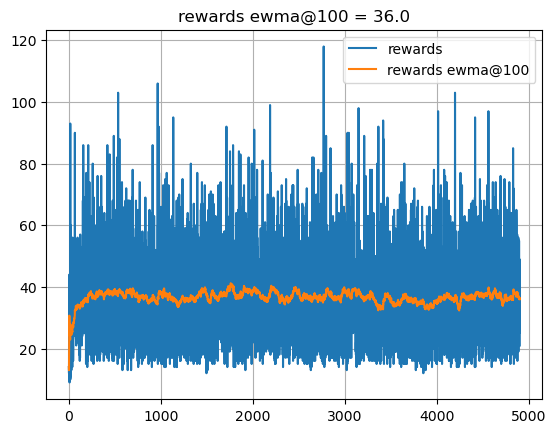

In [140]:

for i in range(5000):
    reward = play_and_train(env, agent)
    rewards.append(reward)

    if i % 100 == 0:
        rewards_ewma = moving_average(rewards)

        clear_output(True)
        plt.plot(rewards, label="rewards")
        plt.plot(rewards_ewma, label="rewards ewma@100")
        plt.legend()
        plt.grid()
        plt.title("rewards ewma@100 = {:.1f}".format(rewards_ewma[-1]))
        plt.show()

In [141]:
print("Your agent has learned {} Q-values.".format(len(agent._qvalues)))

Your agent has learned 3349 Q-values.


## Step 3: EV-SARSA with softmax policy

Политика, которую мы собираемся использовать, по-прежнему softmax, но теперь значение состояния вычисляется по-другому.

Мы наследуем от существующей реализации `QLearningAgent` и обновляем только метод `get_value`.

In [150]:
class EVSarsaAgent(QLearningAgent):
    """
    Агент, который изменяет функции q-learning для реализации ожидаемого значения SARSA.

    Примечание: в этой демонстрации предполагается, 
    что ваша реализация QLearningAgent.update использует get_value(next_state).
    
    Если этого не произойдет, пожалуйста, добавьте
    def update(self, state, action, reward, next_state):
    и реализуйте его для получения ожидаемого значения V(s') SARSA
    """

    def get_value(self, state):
        """
        Верните Vpi для текущего состояния в соответствии с политикой softmax:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Подсказка: все остальные методы из QLearningAgent по-прежнему доступны.
        """
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return 0.0

        # YOUR CODE HERE
        # Вычислите значение текущего состояния в соответствии с политикой softmax.
        
        # q_values = np.array([self.get_q_value(state, action) for action in possible_actions])
        q_values = np.array([self.get_qvalue(state, action) for action in possible_actions])
        
        # Softmax policy
        probs = self.get_softmax_policy(state)
        
        # Ожидаемое значение по политике
        value = np.sum(probs * q_values)
        assert value is not None
        return value

### Cliff World

Давайте теперь посмотрим, как наш алгоритм соотносится с q-обучением в случае, когда мы заставляем агента постоянно исследовать.

<img src=https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/cliffworld.png width=600>
<center><i>Image from CS188</i></center>

In [151]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
n_actions = env.action_space.n

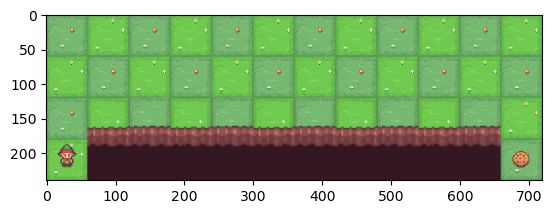

In [152]:
# Наш мир утесов отличается от того, что изображено на картинке, одним: здесь нет стен.
# Агент может подойти к утесу так близко, как пожелает.
# x: начало, T: выход, C: утес, o: ровная площадка

env.reset()
plt.imshow(env.render())

In [153]:
agent_sarsa = EVSarsaAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

agent_ql = QLearningAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

EVSARSA mean reward = -18.04
QLEARNING mean reward = -23.79


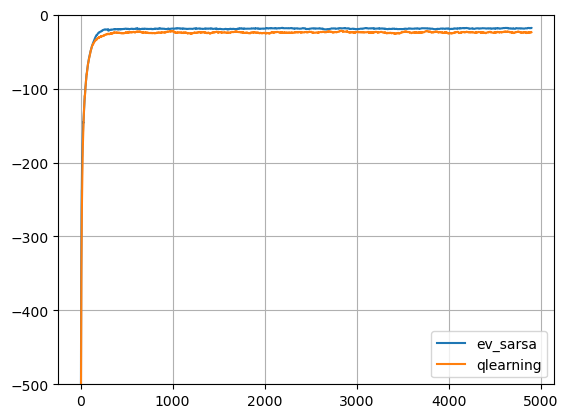

In [154]:
from IPython.display import clear_output


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


rewards_sarsa, rewards_ql = [], []

for i in range(5000):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))

    if i % 100 == 0:
        clear_output(True)
        print("EVSARSA mean reward =", np.mean(rewards_sarsa[-100:]))
        print("QLEARNING mean reward =", np.mean(rewards_ql[-100:]))
        plt.plot(moving_average(rewards_sarsa), label="ev_sarsa")
        plt.plot(moving_average(rewards_ql), label="qlearning")
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

Давайте теперь посмотрим, чему научились алгоритмы, визуализируя свои действия в каждом состоянии.

In [155]:
def draw_policy(agent):
    """Prints CliffWalkingEnv policy with arrows. Hard-coded."""

    env = gym.make("CliffWalking-v1", render_mode="ansi")
    env.reset()
    grid = [x.split("  ") for x in env.render().split("\n")[:4]]

    n_rows, n_cols = 4, 12
    start_state_index = 36
    actions = "^>v<"

    for yi in range(n_rows):
        for xi in range(n_cols):
            if grid[yi][xi] == "C":
                print(" C ", end="")
            elif (yi * n_cols + xi) == start_state_index:
                print(" X ", end="")
            elif (yi * n_cols + xi) == n_rows * n_cols - 1:
                print(" T ", end="")
            else:
                print(" %s " % actions[agent.get_best_action(yi * n_cols + xi)], end="")
        print()

In [156]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

Q-Learning
 >  >  >  >  >  >  >  >  >  >  v  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 
SARSA
 >  >  >  >  >  >  >  >  v  v  v  v 
 >  >  >  >  >  >  >  >  >  >  v  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 


Поздравляю! Наконец, скопируйте `QLearningAgent`, `EVSarsaAgent` и `my_softmax` в шаблон и отправьте их на конкурс.

Удачи!